# Fase 3.1 — Análisis de Importancia por Enfermedad con SHAP
**Objetivo:** Explicar qué biomarcadores son más predictivos para cada condición usando SHAP values.

Se generan cuatro tipos de visualizaciones:
1. Beeswarm plot — importancia y dirección por biomarcador
2. Bar plot — importancia promedio por enfermedad
3. Heatmap — comparación entre todas las enfermedades
4. Waterfall — explicación de un paciente individual

## 0. Imports y configuración

In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import shap
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.base import clone

shap.initjs()

## 1. Carga y preparación de datos

In [4]:
df = pd.read_csv(r"../data_test/NHANES_2017_2020_labeled_diseases.csv")

print(f'Shape: {df.shape}')
print(f'\nDistribución de clases:')
print(df['condition'].value_counts())

Shape: (4812, 11)

Distribución de clases:
condition
healthy             3766
borderline           410
thalassemia          347
thrombocytopenia     204
anemia                85
Name: count, dtype: int64


In [5]:
TARGET_COL = 'condition'

X = df.drop(columns=[TARGET_COL])
X = X.select_dtypes(include=[np.number])
feature_names = list(X.columns)

le = LabelEncoder()
y  = le.fit_transform(df[TARGET_COL])
clases = list(le.classes_)

# Partición 70/30 estratificada
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)

# Imputar NaN con mediana ANTES de pasar a SHAP
imputer = SimpleImputer(strategy='median')
X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), columns=feature_names)
X_test_imp  = pd.DataFrame(imputer.transform(X_test),      columns=feature_names)

print(f'Features   : {len(feature_names)}')
print(f'Clases     : {clases}')
print(f'Train size : {len(y_train)}')
print(f'Test size  : {len(y_test)}')

Features   : 10
Clases     : ['anemia', 'borderline', 'healthy', 'thalassemia', 'thrombocytopenia']
Train size : 3368
Test size  : 1444


## 2. Entrenamiento del modelo Random Forest

In [6]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_imp, y_train)

acc = (rf.predict(X_test_imp) == y_test).mean()
print(f'Accuracy en test: {acc:.4f} ')

Accuracy en test: 0.9993 


## 3. Cálculo de SHAP values

Se usa `TreeExplainer` que es el más eficiente para Random Forest.
Produce una matriz de SHAP values de forma `(n_muestras, n_features, n_clases)`.

In [9]:
print('Calculando SHAP values')
explainer   = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test_imp)

# shap_values es una lista de arrays, uno por clase
# Forma de cada array: (n_muestras, n_features)
print(f'SHAP values calculados')
print(f'Número de clases : {len(shap_values)}')
print(f'Shape por clase  : {shap_values[0].shape}')
print(f'Clases           : {clases}')

Calculando SHAP values
SHAP values calculados
Número de clases : 1444
Shape por clase  : (10, 5)
Clases           : ['anemia', 'borderline', 'healthy', 'thalassemia', 'thrombocytopenia']


## 4. Beeswarm plots — importancia y dirección por enfermedad

Cada punto es un paciente. El color indica el valor del biomarcador (rojo=alto, azul=bajo).
La posición en el eje X indica cuánto empuja ese biomarcador hacia esa enfermedad.

Tipo: <class 'numpy.ndarray'>
Forma: (1444, 10, 5)
Generando beeswarm para: anemia


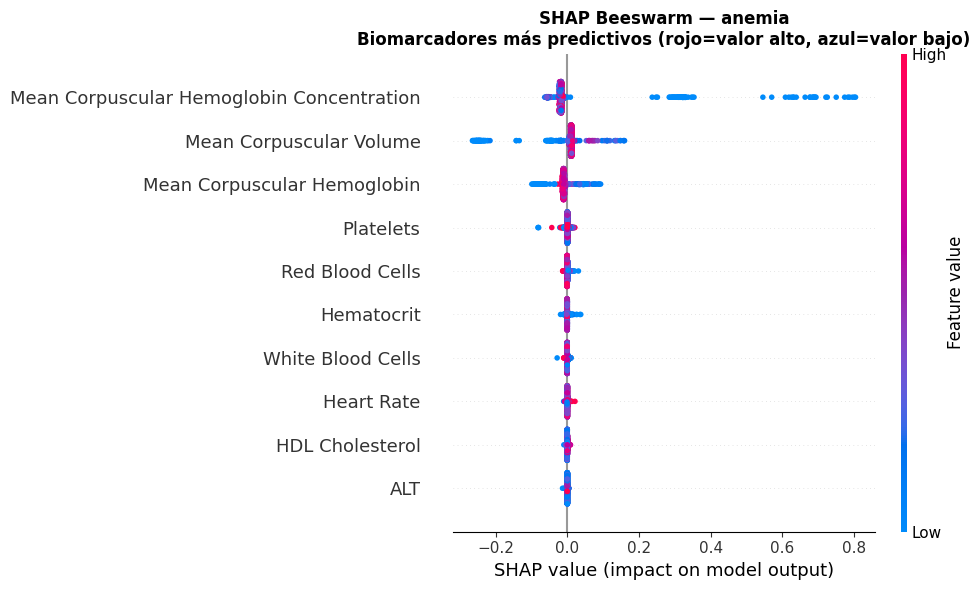

Generando beeswarm para: borderline


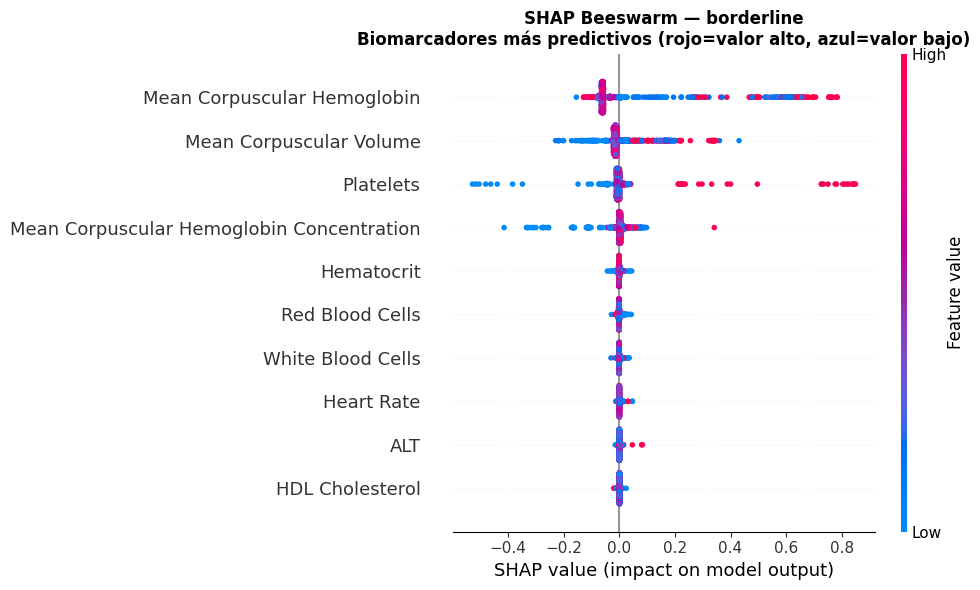

Generando beeswarm para: healthy


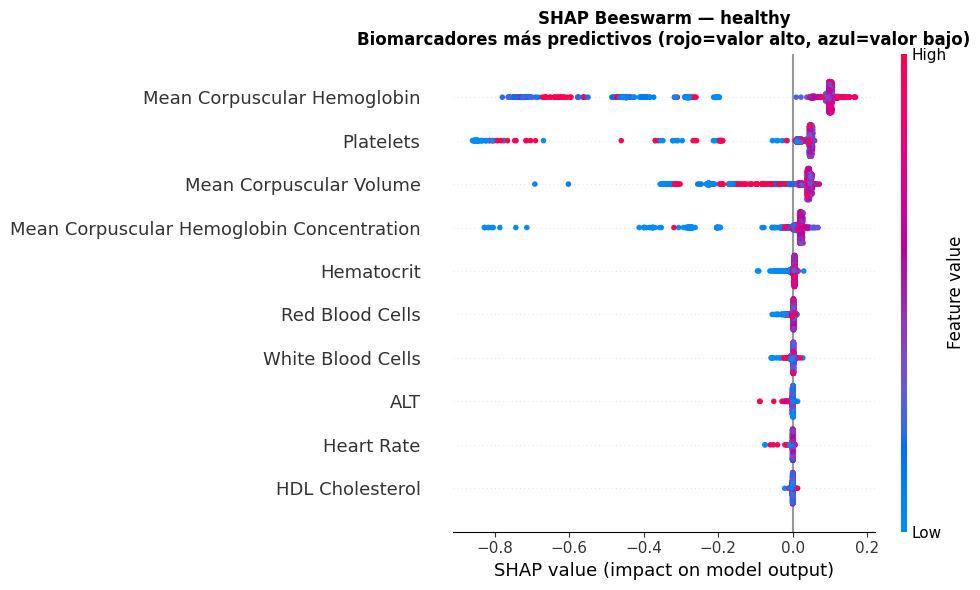

Generando beeswarm para: thalassemia


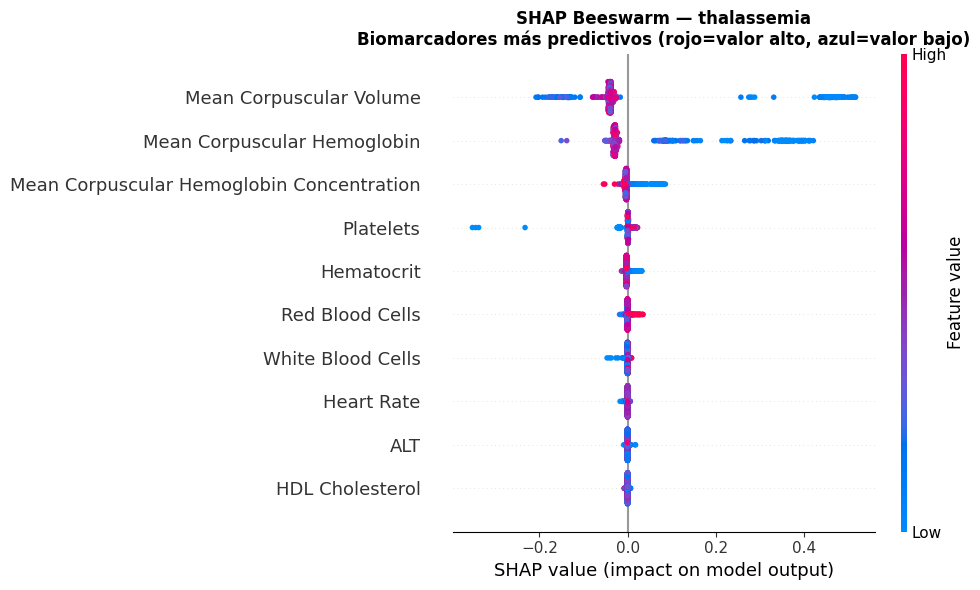

Generando beeswarm para: thrombocytopenia


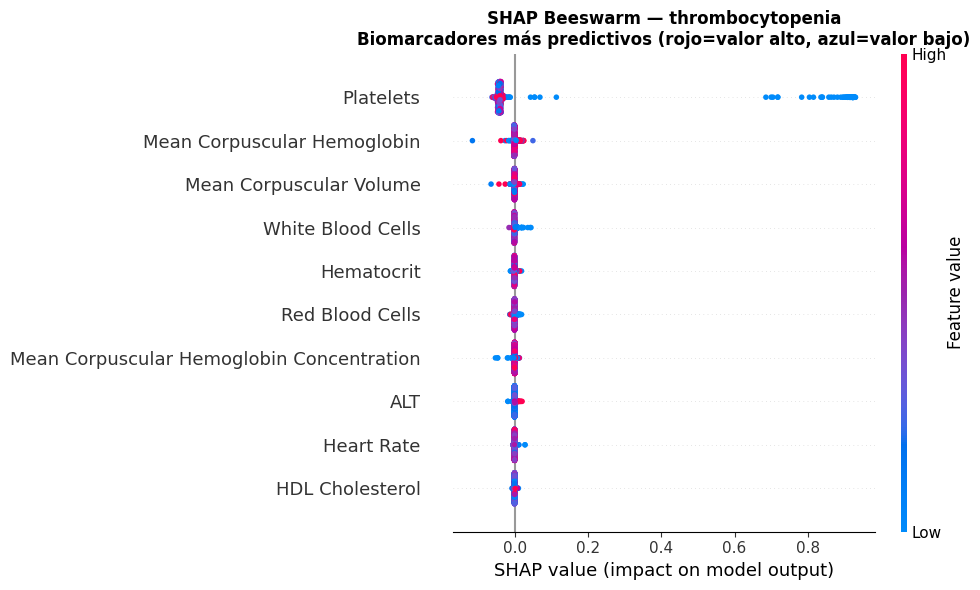

In [11]:
os.makedirs('../img', exist_ok=True)

# Verificar formato de shap_values
print(f'Tipo: {type(shap_values)}')
print(f'Forma: {np.array(shap_values).shape}')

for i, clase in enumerate(clases):
    print(f'Generando beeswarm para: {clase}')
    
    # Extraer los valores correctos según el formato
    if isinstance(shap_values, list):
        sv = shap_values[i]  # formato antiguo: lista de arrays
    else:
        sv = shap_values[:, :, i]  # formato nuevo: array 3D
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    shap.summary_plot(
        sv,
        X_test_imp,
        feature_names=feature_names,
        plot_type='dot',
        max_display=10,
        show=False,
        plot_size=None
    )
    
    plt.title(f'SHAP Beeswarm — {clase}\n'
              f'Biomarcadores más predictivos (rojo=valor alto, azul=valor bajo)',
              fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'../img/shap_beeswarm_{clase.lower().replace(" ", "_")}.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()



## 5. Bar plots — top 10 biomarcadores por enfermedad

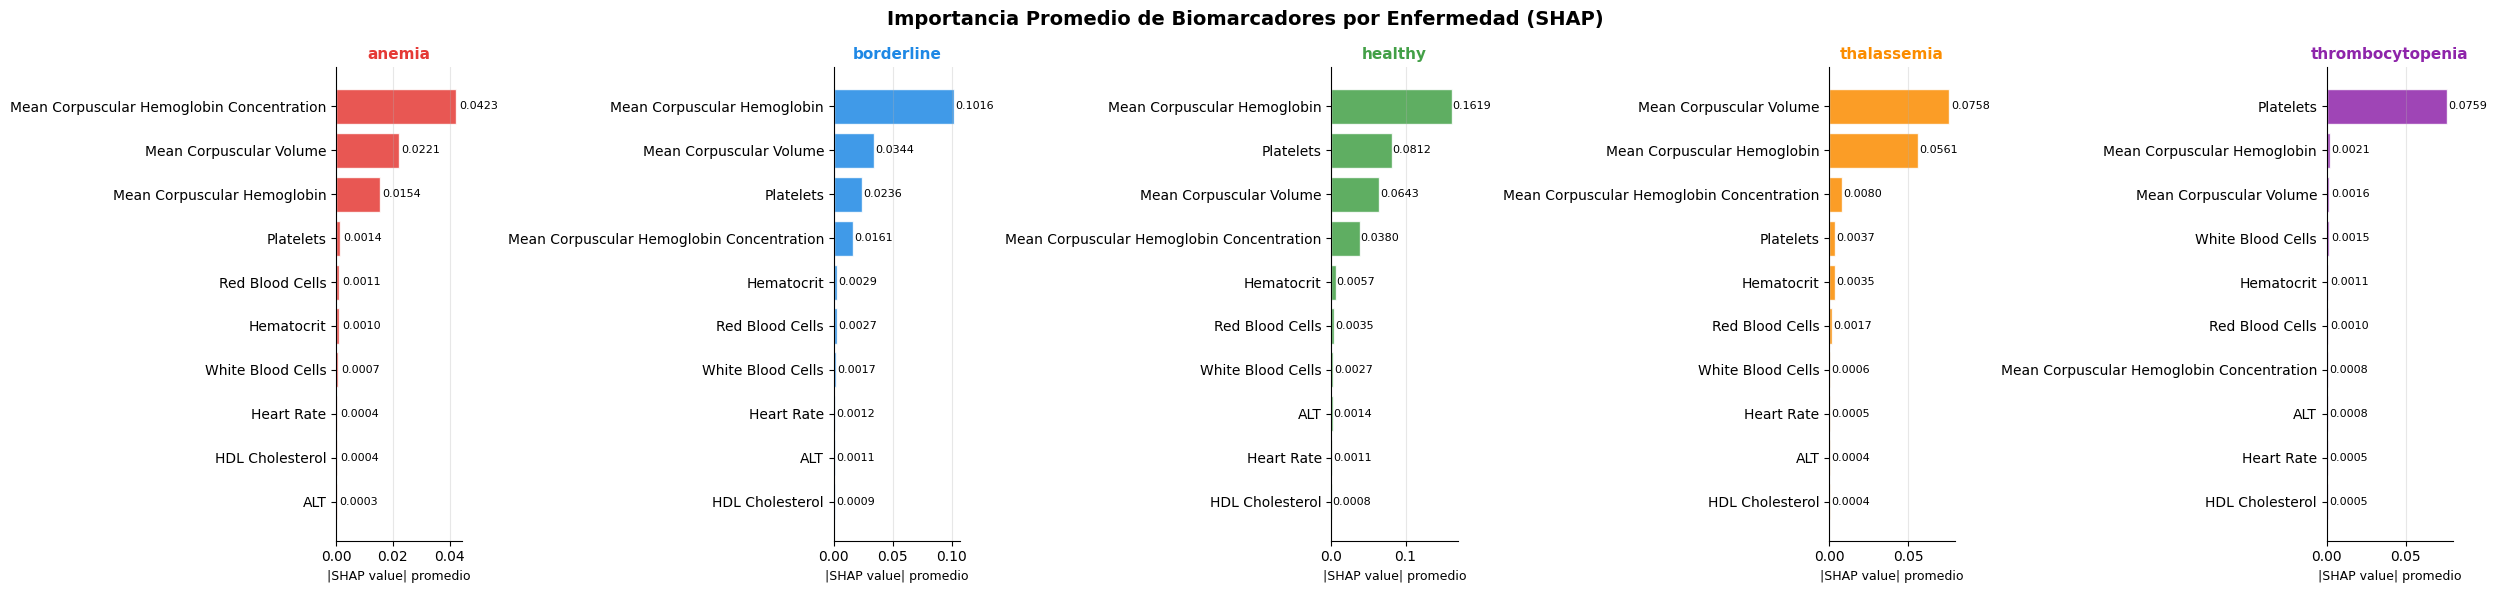

In [12]:
colores_clases = {
    0: '#E53935',  
    1: '#1E88E5', 
    2: '#43A047', 
    3: '#FB8C00',  
    4: '#8E24AA', 
}

fig, axes = plt.subplots(1, len(clases), figsize=(5 * len(clases), 6))
fig.suptitle('Importancia Promedio de Biomarcadores por Enfermedad (SHAP)',
             fontsize=14, fontweight='bold')

if len(clases) == 1:
    axes = [axes]

for i, (clase, ax) in enumerate(zip(clases, axes)):
    # Extraer valores según formato
    if isinstance(shap_values, list):
        sv = shap_values[i]
    else:
        sv = shap_values[:, :, i]
    
    mean_abs_shap = np.abs(sv).mean(axis=0)
    # ... resto del código igual
    
    # Top 10
    top_idx    = np.argsort(mean_abs_shap)[-10:]
    top_vals   = mean_abs_shap[top_idx]
    top_names  = [feature_names[j] for j in top_idx]
    
    color = colores_clases.get(i, '#546E7A')
    bars  = ax.barh(top_names, top_vals, color=color, alpha=0.85, edgecolor='white')
    
    for bar, val in zip(bars, top_vals):
        ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=8)
    
    ax.set_title(clase, fontsize=11, fontweight='bold', color=color)
    ax.set_xlabel('|SHAP value| promedio', fontsize=9)
    ax.grid(axis='x', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../img/shap_barplot_por_enfermedad.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Heatmap — comparación de importancia entre todas las enfermedades

Permite ver de un vistazo qué biomarcadores son específicos de una enfermedad y cuáles son compartidos.

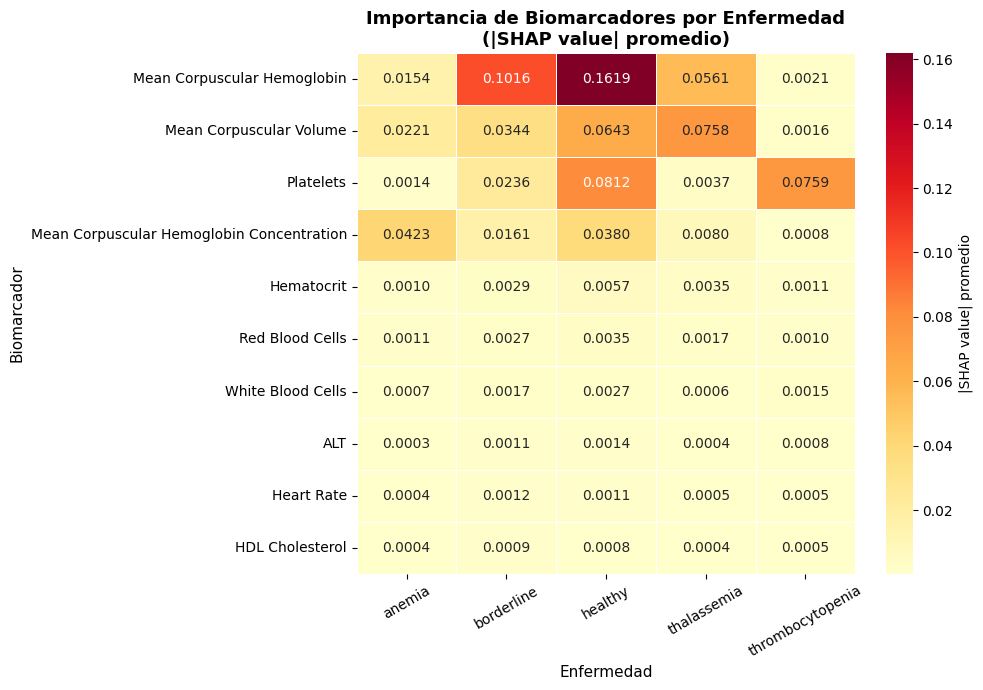

In [13]:
# Construir matriz: filas = biomarcadores, columnas = enfermedades
importancia_matrix = np.zeros((len(feature_names), len(clases)))

for i in range(len(clases)):
    if isinstance(shap_values, list):
        sv = shap_values[i]
    else:
        sv = shap_values[:, :, i]
    importancia_matrix[:, i] = np.abs(sv).mean(axis=0)

df_heatmap = pd.DataFrame(
    importancia_matrix,
    index=feature_names,
    columns=clases
)

# Ordenar por importancia total descendente
df_heatmap['total'] = df_heatmap.sum(axis=1)
df_heatmap = df_heatmap.sort_values('total', ascending=False).drop(columns='total')

# Tomar top 12 biomarcadores
df_heatmap = df_heatmap.head(12)

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(
    df_heatmap,
    annot=True,
    fmt='.4f',
    cmap='YlOrRd',
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': '|SHAP value| promedio'}
)

ax.set_title('Importancia de Biomarcadores por Enfermedad\n(|SHAP value| promedio)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Enfermedad', fontsize=11)
ax.set_ylabel('Biomarcador', fontsize=11)
ax.tick_params(axis='x', rotation=30)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('../img/shap_heatmap_comparativo.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Waterfall plot — explicación de un paciente individual

Muestra por qué el modelo tomó esa decisión para UN paciente específico.
Muy útil para demostrar interpretabilidad clínica.

Forma shap_exp: (1444, 10, 5)


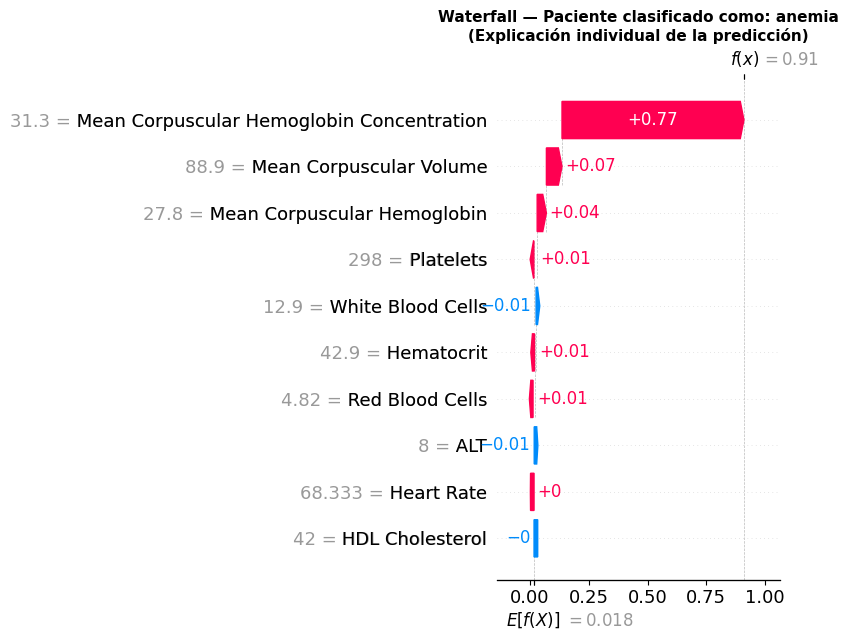

✓ Waterfall generado para: anemia


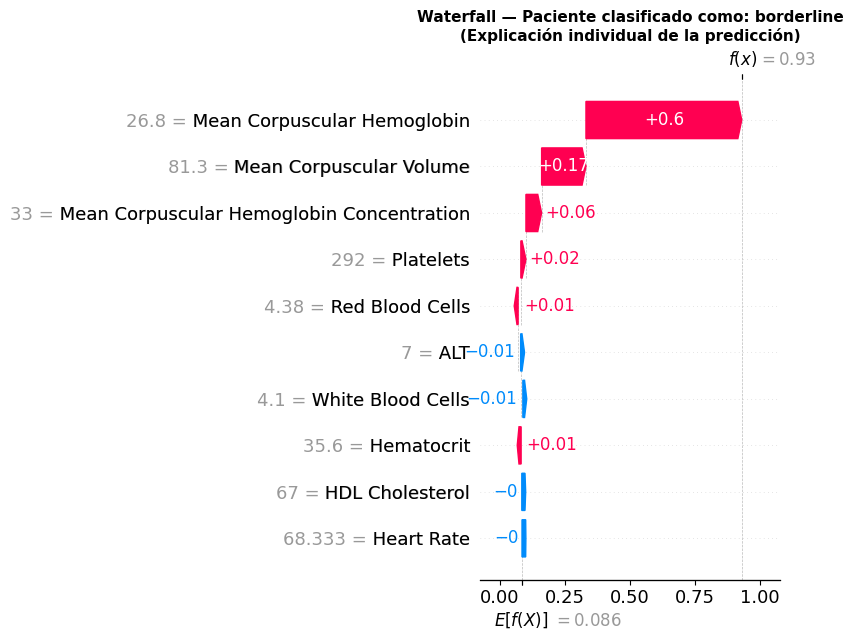

✓ Waterfall generado para: borderline


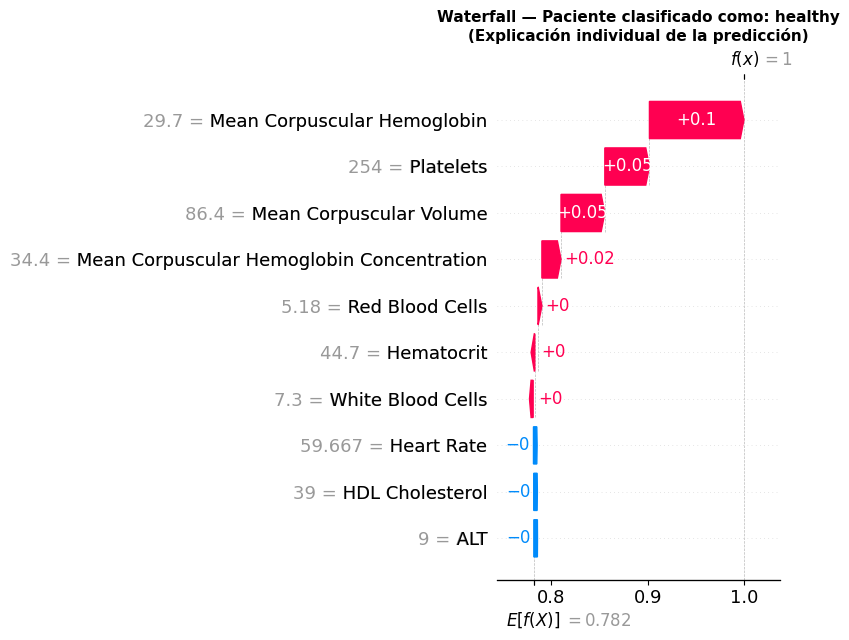

✓ Waterfall generado para: healthy


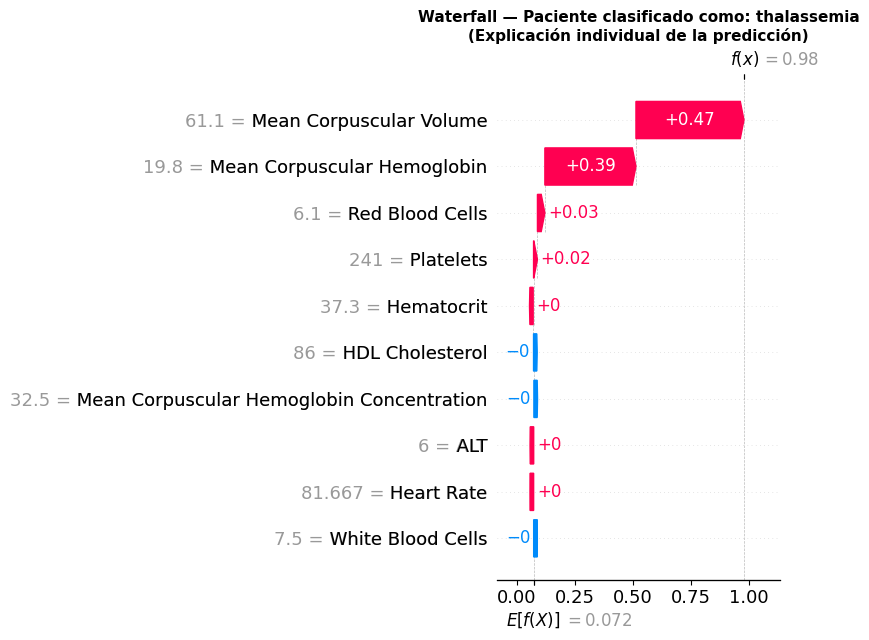

✓ Waterfall generado para: thalassemia


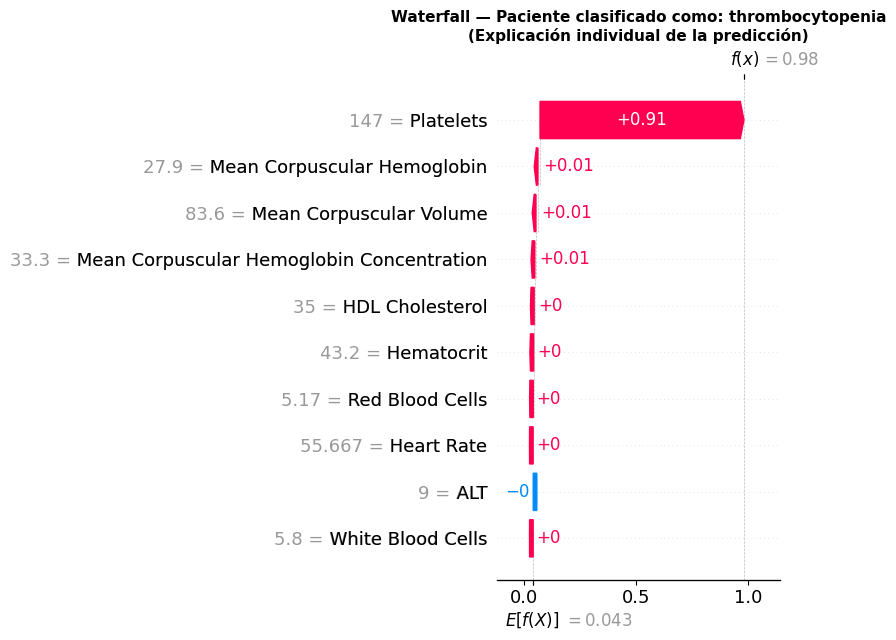

✓ Waterfall generado para: thrombocytopenia


In [15]:

explainer2 = shap.TreeExplainer(rf)
shap_exp   = explainer2(X_test_imp)

# shap_exp tiene forma (n_muestras, n_features, n_clases)
print(f'Forma shap_exp: {shap_exp.shape}')

y_pred = rf.predict(X_test_imp)

for i, clase in enumerate(clases):
    # Buscar paciente correctamente clasificado en esta clase
    idx_clase = np.where((y_pred == i) & (y_test == i))[0]
    
    if len(idx_clase) == 0:
        print(f'No hay pacientes correctamente clasificados como {clase}, saltando...')
        continue
    
    paciente_idx = idx_clase[0]
    
    plt.figure(figsize=(10, 5))
    shap.waterfall_plot(
        shap_exp[paciente_idx, :, i],
        max_display=10,
        show=False
    )
    plt.title(f'Waterfall — Paciente clasificado como: {clase}\n'
              f'(Explicación individual de la predicción)',
              fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'../img/shap_waterfall_{clase.lower().replace(" ", "_")}.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f'✓ Waterfall generado para: {clase}')



## 8. Tabla resumen — top 3 biomarcadores por enfermedad

In [16]:
print('='*65)
print('TOP 3 BIOMARCADORES POR ENFERMEDAD (según SHAP)')
print('='*65)

resumen_shap = []

for i, clase in enumerate(clases):
    mean_abs = np.abs(shap_values[i]).mean(axis=0)
    top3_idx = np.argsort(mean_abs)[-3:][::-1]
    
    print(f'\n{clase}:')
    for rank, idx in enumerate(top3_idx, 1):
        print(f'  {rank}. {feature_names[idx]:<40} SHAP: {mean_abs[idx]:.4f}')
        resumen_shap.append({
            'Enfermedad' : clase,
            'Rank'       : rank,
            'Biomarcador': feature_names[idx],
            'SHAP medio' : round(mean_abs[idx], 4)
        })

df_resumen = pd.DataFrame(resumen_shap)
df_resumen.to_csv('../resultados_fase3_1_shap.csv', index=False)


TOP 3 BIOMARCADORES POR ENFERMEDAD (según SHAP)

anemia:
  1. Red Blood Cells                          SHAP: 0.0220
  2. White Blood Cells                        SHAP: 0.0095
  3. Hematocrit                               SHAP: 0.0075

borderline:
  1. Hematocrit                               SHAP: 0.0915
  2. Red Blood Cells                          SHAP: 0.0819
  3. White Blood Cells                        SHAP: 0.0134

healthy:
  1. Red Blood Cells                          SHAP: 0.0220
  2. White Blood Cells                        SHAP: 0.0102
  3. Hematocrit                               SHAP: 0.0080

thalassemia:
  1. Red Blood Cells                          SHAP: 0.0220
  2. White Blood Cells                        SHAP: 0.0096
  3. Hematocrit                               SHAP: 0.0075

thrombocytopenia:
  1. Red Blood Cells                          SHAP: 0.0218
  2. White Blood Cells                        SHAP: 0.0086
  3. Hematocrit                               SHAP: 0.0074


------------------------------------------------------------------------------------

-----------------------------------------------------------------------------------

In [17]:
import pandas as pd

df = pd.read_csv(r"../data_test/NHANES_2017_2020_labeled_diseases.csv")

# Verificar si hay pacientes duplicados (mismo SEQN con diferentes condiciones)
print("¿Tiene columna SEQN?", 'SEQN' in df.columns)
print(f"Total filas: {len(df)}")
print(f"Columnas: {list(df.columns)}")
print(f"\nValores únicos en condition:")
print(df['condition'].value_counts())

# Ver si hay IDs repetidos
if 'SEQN' in df.columns:
    duplicados = df[df.duplicated('SEQN', keep=False)]
    print(f"\nPacientes con más de una fila (SEQN repetido): {df['SEQN'].duplicated().sum()}")
    if len(duplicados) > 0:
        print("\nEjemplo de paciente con múltiples condiciones:")
        print(duplicados.head(10))
else:
    print("\nNo hay columna SEQN — revisando duplicados por todas las features:")
    cols_features = [c for c in df.columns if c != 'condition']
    dups = df[df.duplicated(subset=cols_features, keep=False)]
    print(f"Filas con features idénticas pero diferente condición: {len(dups)}")
    if len(dups) > 0:
        print(dups.head(10))

¿Tiene columna SEQN? False
Total filas: 4812
Columnas: ['Platelets', 'White Blood Cells', 'Red Blood Cells', 'Hematocrit', 'Mean Corpuscular Volume', 'Mean Corpuscular Hemoglobin', 'Mean Corpuscular Hemoglobin Concentration', 'HDL Cholesterol', 'ALT', 'Heart Rate', 'condition']

Valores únicos en condition:
condition
healthy             3766
borderline           410
thalassemia          347
thrombocytopenia     204
anemia                85
Name: count, dtype: int64

No hay columna SEQN — revisando duplicados por todas las features:
Filas con features idénticas pero diferente condición: 0


In [18]:
import os

# Buscar archivos CSV en todo el repositorio
for carpeta in ['../data', '../data_test', '.']:
    if os.path.exists(carpeta):
        archivos = os.listdir(carpeta)
        print(f'\nCarpeta {carpeta}:')
        for f in archivos:
            print(f'  {f}')


Carpeta ../data:
  Blood_samples_dataset_balanced_2(f).csv
  blood_samples_dataset_test.csv
  diabetes.csv

Carpeta ../data_test:
  NHANES_2017-2020_completo.csv
  NHANES_2017_2020_labeled_diseases.csv
  NHANES_2017_2020_reetiquetado.csv
  P_BIOPRO.xpt
  P_BMX.xpt
  P_BPXO.xpt
  P_CBC.xpt
  P_DEMO.xpt
  P_GHB.xpt
  P_GLU.xpt
  P_HDL.xpt
  P_HSCRP.xpt
  P_INS.xpt
  P_TCHOL.xpt
  P_TRIGLY.xpt

Carpeta .:
  3_1_SHAP_Importancia.ipynb


In [21]:
df_reet = pd.read_csv('../data_test/NHANES_2017_2020_reetiquetado.csv')
print(f'Shape: {df_reet.shape}')
print(f'\nColumnas: {list(df_reet.columns)}')
print(f'\nPrimeras filas:')
print(df_reet.head())
print(f'\nValores únicos por columna de condición:')
for col in df_reet.columns:
    if df_reet[col].dtype == object:
        print(f'\n{col}:')
        print(df_reet[col].value_counts())




Shape: (5090, 10)

Columnas: ['Platelets', 'White Blood Cells', 'Red Blood Cells', 'Hematocrit', 'Mean Corpuscular Volume', 'Mean Corpuscular Hemoglobin', 'Mean Corpuscular Hemoglobin Concentration', 'HDL Cholesterol', 'ALT', 'Heart Rate']

Primeras filas:
   Platelets  White Blood Cells  Red Blood Cells  Hematocrit  \
0      263.0                4.5             4.80        40.5   
1      254.0                5.5             4.54        44.3   
2      173.0                3.7             4.47        41.3   
3      224.0                7.9             4.41        38.5   
4      154.0                4.0             4.16        38.0   

   Mean Corpuscular Volume  Mean Corpuscular Hemoglobin  \
0                     84.3                         28.4   
1                     97.6                         33.5   
2                     92.3                         31.0   
3                     87.2                         29.1   
4                     91.2                         30.9   

   

In [22]:
df_sint = pd.read_csv('../data/Blood_samples_dataset_balanced_2(f).csv')
print(f'\nShape sintético: {df_sint.shape}')
print(f'Columnas: {list(df_sint.columns)}')
print(f'\nClases:')
print(df_sint['Disease'].value_counts() if 'Disease' in df_sint.columns else df_sint.iloc[:,-1].value_counts())


Shape sintético: (2351, 25)
Columnas: ['Glucose', 'Cholesterol', 'Hemoglobin', 'Platelets', 'White Blood Cells', 'Red Blood Cells', 'Hematocrit', 'Mean Corpuscular Volume', 'Mean Corpuscular Hemoglobin', 'Mean Corpuscular Hemoglobin Concentration', 'Insulin', 'BMI', 'Systolic Blood Pressure', 'Diastolic Blood Pressure', 'Triglycerides', 'HbA1c', 'LDL Cholesterol', 'HDL Cholesterol', 'ALT', 'AST', 'Heart Rate', 'Creatinine', 'Troponin', 'C-reactive Protein', 'Disease']

Clases:
Disease
Anemia      623
Healthy     556
Diabetes    540
Thalasse    509
Thromboc    123
Name: count, dtype: int64
